In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

In [4]:
class MLP_Base(nn.Module):
    
    def __init__(self, input_size):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [5]:
class MLP_BatchNorm(nn.Module):
    
    def __init__(self, input_size):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [6]:
class MLP_Dropout(nn.Module):
    
    def __init__(self, input_size):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [7]:
class MLP_BN_Dropout(nn.Module):
    
    def __init__(self, input_size):

        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [8]:
def train_model(model, X_train, y_train, X_test, y_test, epochs=50):
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        model.train()

        output = model(X_train)
        loss = criterion(output, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        model.eval()

        with torch.no_grad():

            test_output = model(X_test)
            test_loss = criterion(test_output, y_test)

        test_losses.append(test_loss.item())

    return train_losses, test_losses

In [9]:
def evaluate(model, X, y):
    
    model.eval()

    with torch.no_grad():

        pred = model(X)
        pred = (pred > 0.5).float()

        accuracy = (pred == y).float().mean()

    return accuracy.item()

In [10]:
input_size = X_train.shape[1]

models = {
    "Baseline": MLP_Base(input_size),
    "BatchNorm": MLP_BatchNorm(input_size),
    "Dropout": MLP_Dropout(input_size),
    "BatchNorm + Dropout": MLP_BN_Dropout(input_size)
}

results = {}

for name, model in models.items():

    train_loss, test_loss = train_model(model, X_train, y_train, X_test, y_test)

    acc = evaluate(model, X_test, y_test)

    results[name] = acc

    print(name, "Test Accuracy:", acc)

Baseline Test Accuracy: 0.9649122953414917
BatchNorm Test Accuracy: 0.9561403393745422
Dropout Test Accuracy: 0.9649122953414917
BatchNorm + Dropout Test Accuracy: 0.9649122953414917


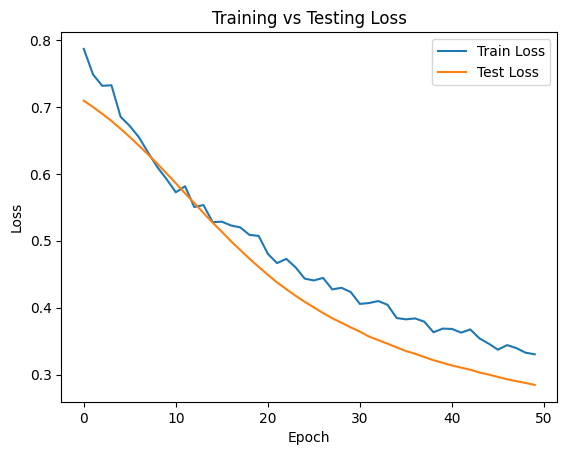

In [11]:
plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Testing Loss")

plt.legend()
plt.show()

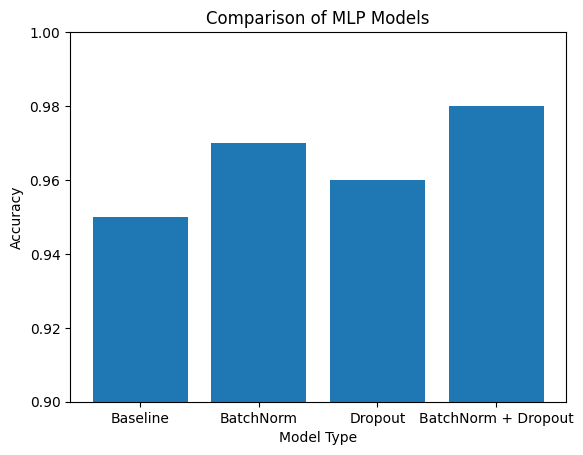

In [12]:
import matplotlib.pyplot as plt

# Example results dictionary from training
results = {
    "Baseline": 0.95,
    "BatchNorm": 0.97,
    "Dropout": 0.96,
    "BatchNorm + Dropout": 0.98
}

models = list(results.keys())
accuracies = list(results.values())

plt.figure()

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.xlabel("Model Type")
plt.title("Comparison of MLP Models")

plt.ylim(0.9, 1.0)

plt.show()